In [12]:
from pathlib import Path

from aind_hcr_data_loader import get_hcr_dataset_pairwise
from aind_hcr_qc.constants import Z1_CHANNEL_CMAP_VIBRANT

In [13]:
# notebook setup
DATA_DIR = Path('/root/capsule/data')
BUCKET_NAME = "aind-open-data"
OUTPUT_DIR = Path(f"/root/capsule/code/unmix_filter_QC/plots")

# colors
CHAN_ORDER  = ["488", "514", "561", "594", "638"]
CHAN_COLORS = {k: v for k, v in Z1_CHANNEL_CMAP_VIBRANT.items() if k in CHAN_ORDER}


# notebook configuration
%matplotlib inline
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
dataset, pw_ds, spots = get_hcr_dataset_pairwise(
    mouse_id="782149",
    data_dir=Path("/root/capsule/data"),   # default
    load_spots=True,                        # default
    return_removed=True,                    # include removed spots with a 'removed' column
    coreg_cells_only=True,                     # only load coregistered cells
)

coreg_df = dataset.load_coreg_table()

  [rounds.R1]  HCR_782149_2025-11-05_13-00-00_processed_2025-11-10_20-37-29  →  ✓ attached
  [rounds.R2]  HCR_782149_2025-11-12_13-00-00_processed_2025-11-13_22-04-32  →  ✓ attached
  [rounds.R3]  HCR_782149_2025-11-19_13-00-00_processed_2025-11-21_01-27-24  →  ✓ attached
  [rounds.R4]  HCR_782149_2025-12-04_13-00-00_processed_2025-12-05_22-31-35  →  ✓ attached
  [rounds.R5]  HCR_782149_2025-12-11_13-00-00_processed_2025-12-12_23-45-26  →  ✓ attached
  [derived_assets.roi_shape_metrics]  HCR_782149_2025-11-05_13-00-00_roi-shape-metrics  →  ✓ attached
  [derived_assets.cell_typing]  HCR_782149_cell-typing_2026-03-08_12-00-00  →  ✓ attached
  [derived_assets.pairwise_unmixing]  HCR_782149_pairwise-unmixing_2026-05-23_01-29-46  →  ✓ attached
  [derived_assets.czstack_hcr_coreg]  782149_2025-05-01_ctl-czstack-hcr-coreg_2026-03-03_00-00-00  →  ✓ attached
[DEBUG get_spot_files] key=R1 round_num=1
[DEBUG get_spot_files] folder_path=/root/capsule/data/HCR_782149_2025-11-05_13-00-00_processed_2

/src/aind-hcr-data-loader/src/aind_hcr_data_loader/hcr_dataset.py:2555: UserWarning: [get_spot_files] R1: no unmixed_spots_R1*.pkl found; falling back to R-1 file: unmixed_spots_R-1_minDist_3.pkl
  _warnings.warn(
/src/aind-hcr-data-loader/src/aind_hcr_data_loader/hcr_dataset.py:2564: UserWarning: [get_spot_files] R1: no mixed_spots_R1.pkl found; falling back to R-1 file: mixed_spots_R-1.pkl
  _warnings.warn(


mouse_id: 782149
Could not load metadata for mouse 782149
Cell-typing asset attached: CellTypingFiles(asset='HCR_782149_cell-typing_2026-03-08_12-00-00', basic_results=✓, h5ad=✓)
Coreg asset attached: CoregFiles(asset='782149_2025-05-01_ctl-czstack-hcr-coreg_2026-03-03_00-00-00', coreg_table=✓, czstack_centroids=✓)
HCR Dataset Summary
Mouse ID: 782149
Rounds: R1, R2, R3, R4, R5

Channels by round:
  R1: 405, 488, 561, 594
  R2: 514, 594, 488, 561, 638, 405
  R3: 561, 638, 514, 488, 594, 405
  R4: 638, 488, 514, 561, 594, 405
  R5: 488, 561, 594, 514, 638, 405

Cell-typing: ✓  (CellTypingFiles(asset='HCR_782149_cell-typing_2026-03-08_12-00-00', basic_results=✓, h5ad=✓))

Segmentation files by round:
  R1: resolutions 0, 2, centroids: ✓
  R2: resolutions 0, 2, centroids: ✗
  R3: resolutions 0, 2, centroids: ✗
  R4: resolutions 0, 2, centroids: ✗
  R5: resolutions 0, 2, centroids: ✗

Spot detection files by round:
  R1: channels 594, 488, 561
    594: spots ✓, stats files: 3
    488: spot

In [30]:
spots = unmix_qc_utils.add_intensity_assigned_chan(spots) 

In [5]:
from aind_hcr_qc.viz.single_cell_unmixing import fig_single_cell_unmixing_mg2

In [ ]:
d_assign_neighbor_ratio_1'  'd_assign_neighbor_ratio_2' 'dye_line_dist_ratio' "intensity_assigned_chan"

In [29]:
_um.columns

Index(['spot_id', 'spot_uid', 'spot_uid_int', 'chan', 'chan_spot_id',
       'cell_id', 'round', 'z', 'y', 'x', 'dist', 'r', 'chan_488_intensity',
       'chan_561_intensity', 'chan_594_intensity', 'over_thresh', 'valid_spot',
       'dye_line_dist_ratio', 'unmixed_chan', 'dist_r', 'dist_to_chan_488',
       'dist_to_chan_561', 'd_assignment_ratio', 'd_assign_neighbor_ratio_1',
       'd_assign_neighbor_ratio_2', 'nn5_dist_488', 'nn5_dist_561',
       'chan_514_intensity', 'chan_638_intensity', 'dist_to_chan_514',
       'dist_to_chan_594', 'dist_to_chan_638', 'nn5_dist_514', 'nn5_dist_594',
       'nn5_dist_638', 'removed'],
      dtype='object')

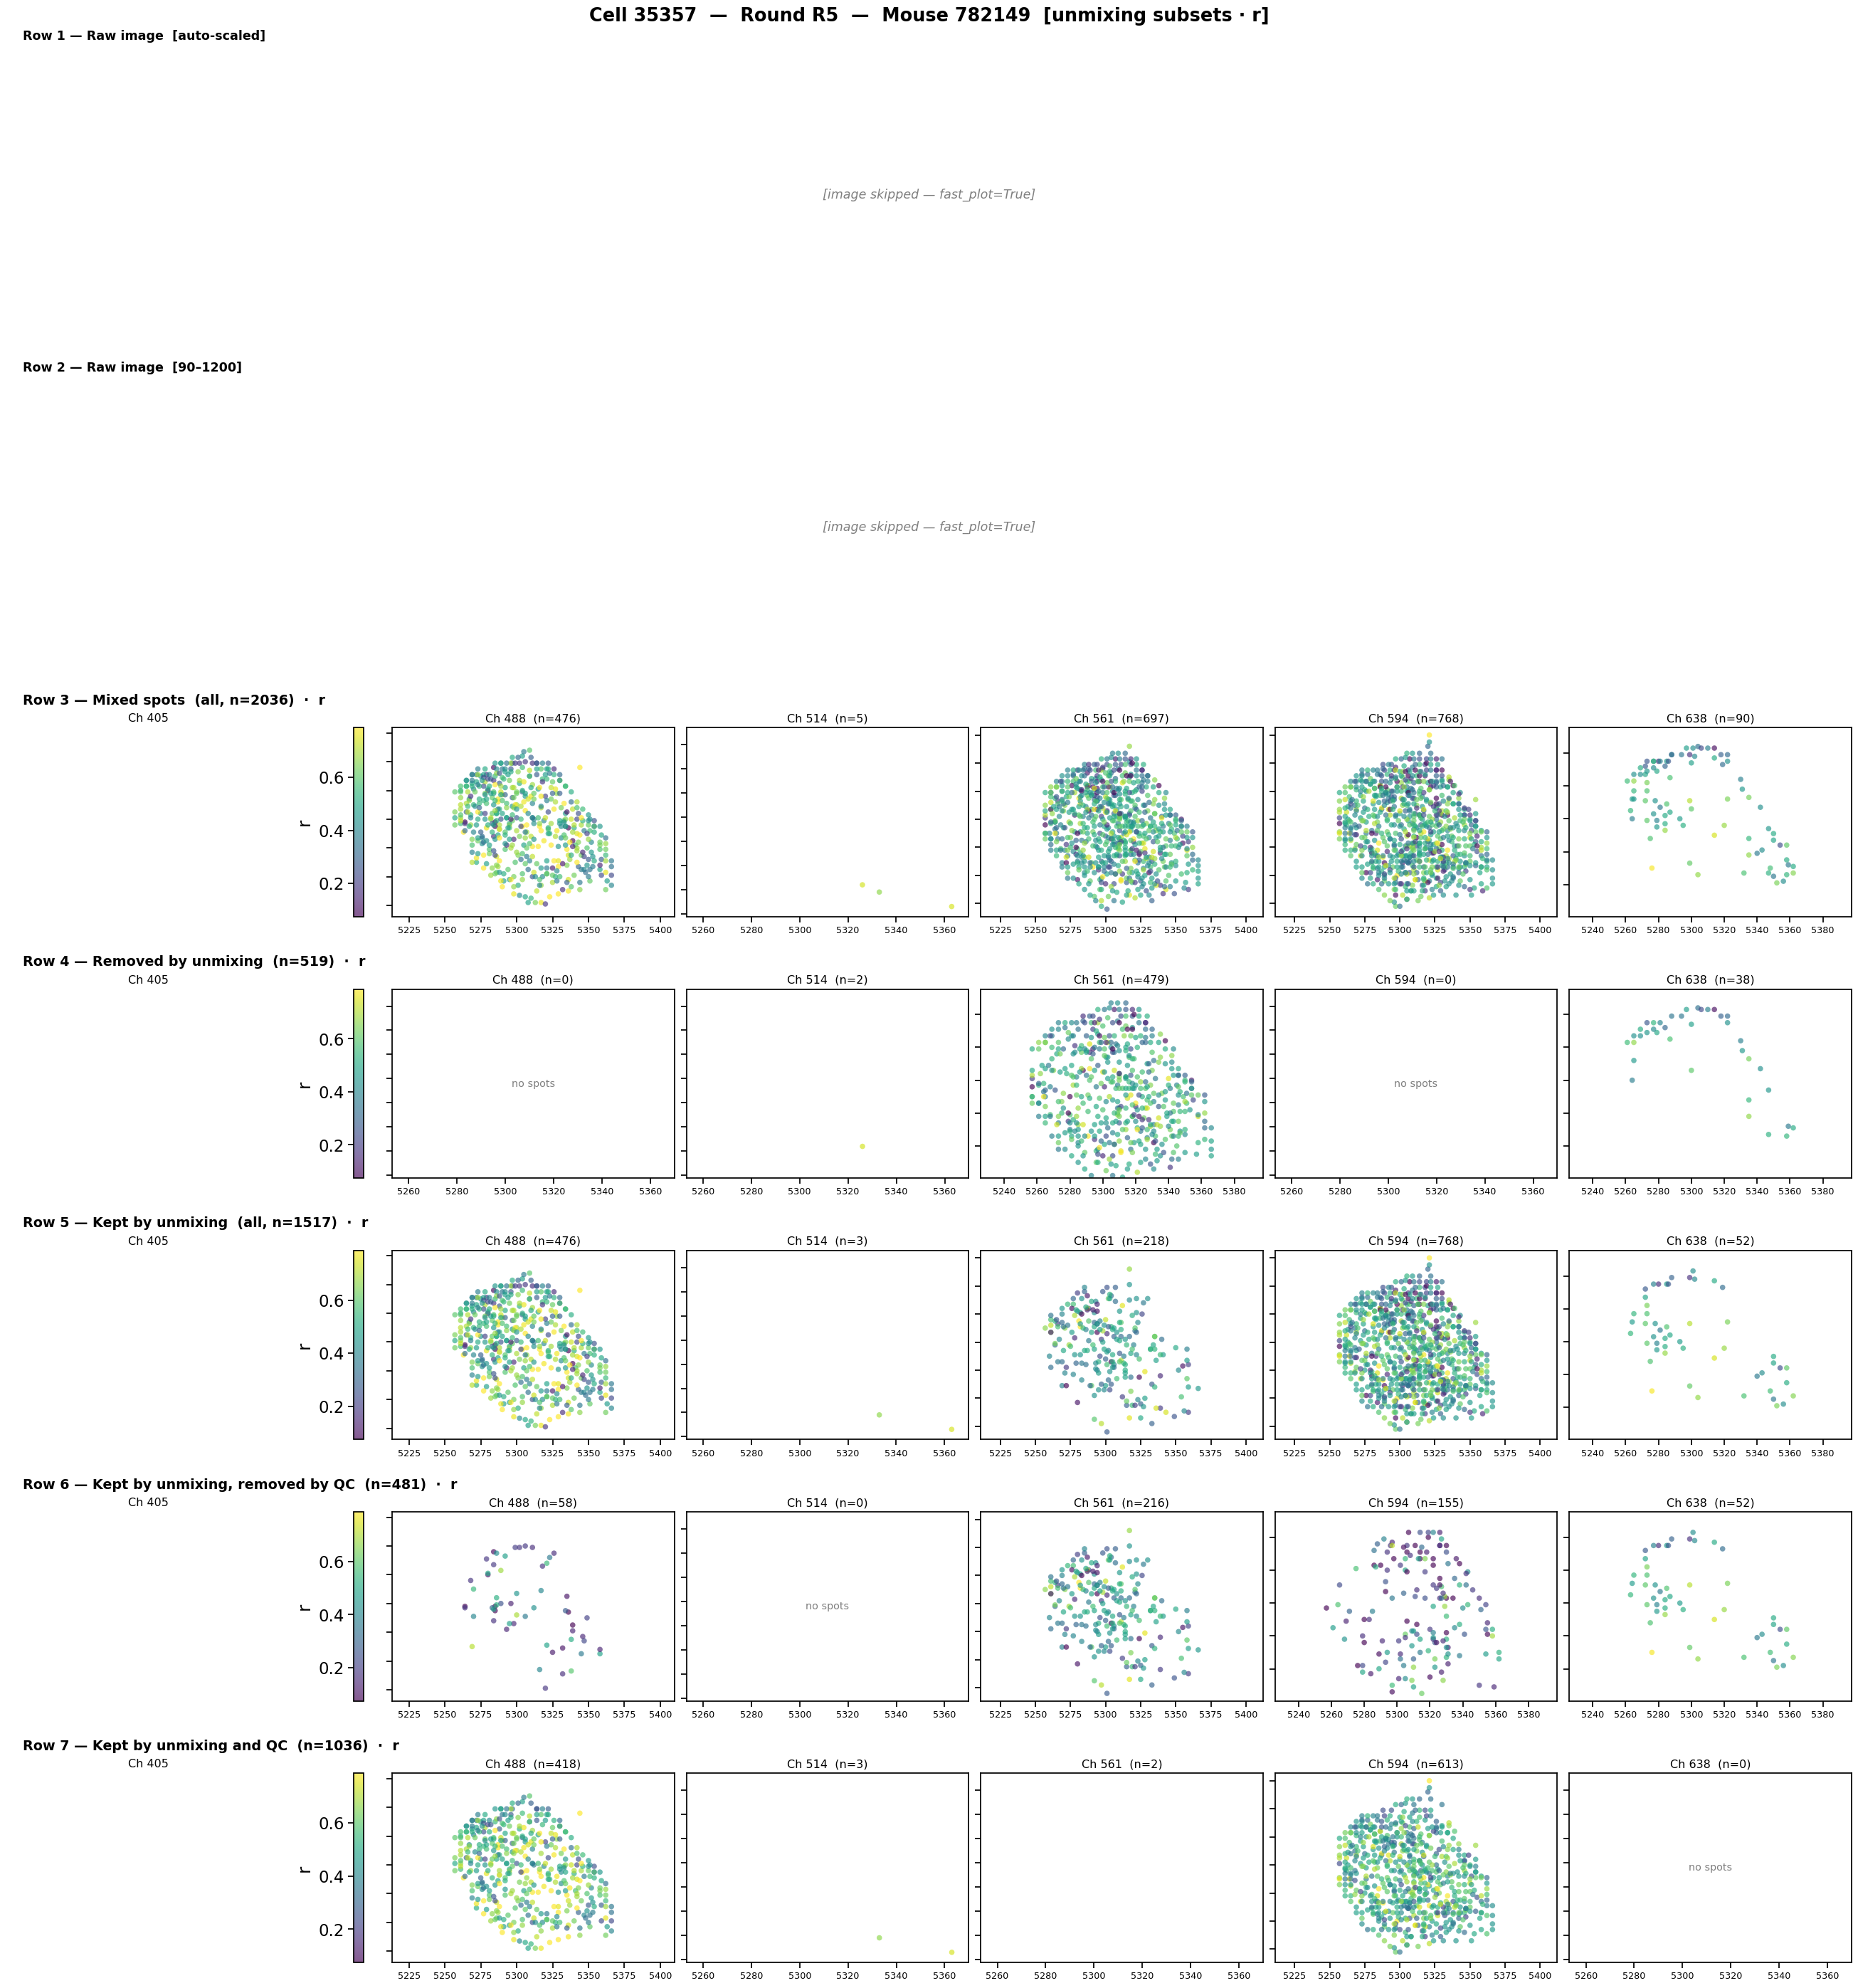

In [ ]:


fig = fig_single_cell_unmixing_mg2(
    _mx, _um,
    cell_id=_test_cid, round_key=_test_rk,
    chan_order=CHAN_ORDER, chan_colors=CHAN_COLORS,
    dataset=dataset,
    fast_plot=True,
    spot_size=30,
    metric_col = 'r'
)

# interactive

In [22]:
import plotly.io as pio
pio.renderers.default = "plotly_mimetype"   # or "vscode"

In [7]:
sys.path.append("/root/capsule/code/unmix_filter_qc/")
import unmix_qc_utils

In [15]:
_test_cid = 35357
_test_rk  = "R5"


_mx = spots[(spots["round"] == _test_rk) & (spots["cell_id"] == _test_cid)]
_um = spots[(spots["round"] == _test_rk) & (spots["cell_id"] == _test_cid) & (spots["removed"] == False)]

In [ ]:
import sys
sys.path.append("/root/capsule/code/unmix_filter_qc")
import unmix_qc_utils

w = unmix_qc_utils.interactive_single_cell_unmixing_plotly(
    _mx, _um,
    cell_id=_test_cid,
    round_key=_test_rk,
    chan_order=CHAN_ORDER,
)



In [32]:
display(w)